# 01 — Análisis Exploratorio de Datos (EDA)
## FraudShield-ML

Exploración del dataset IEEE-CIS Fraud Detection para entender la distribución
del fraude, la calidad de los datos y las relaciones entre variables.

### Objetivos
- Entender el desbalance extremo del target (3.5% fraude)
- Analizar distribuciones de TransactionAmt por clase
- Explorar patrones temporales del fraude
- Identificar variables categóricas relevantes
- Unir los datasets de transacciones e identidad

## 1. Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 2. Rutas del proyecto

In [2]:
# Path al notebook actual → sube un nivel → llega a la raíz del proyecto
PROJECT_ROOT = Path(__file__ if "__file__" in dir() else ".").resolve().parent

# Rutas relativas desde la raíz
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Verificar que las carpetas existen
print("Raíz del proyecto:", PROJECT_ROOT)
print("Datos crudos:", DATA_RAW)
print("¿Carpeta raw existe?", DATA_RAW.exists())

Raíz del proyecto: C:\Users\micke\OneDrive\Desktop\projects\Frauddetection-mlops
Datos crudos: C:\Users\micke\OneDrive\Desktop\projects\Frauddetection-mlops\data\raw
¿Carpeta raw existe? True


## 3. Carga del dataset

Cargamos los 4 archivos CSV del dataset IEEE-CIS:
-  — transacciones con etiqueta de fraude
-  — datos de identidad del comprador
-  y  — datos de evaluación

In [3]:
# Cargar los 4 archivos CSV
train_txn = pd.read_csv(DATA_RAW / "train_transaction.csv")
train_id  = pd.read_csv(DATA_RAW / "train_identity.csv")
test_txn  = pd.read_csv(DATA_RAW / "test_transaction.csv")
test_id   = pd.read_csv(DATA_RAW / "test_identity.csv")

print("train_transaction:", train_txn.shape)
print("train_identity:   ", train_id.shape)
print("test_transaction: ", test_txn.shape)
print("test_identity:    ", test_id.shape)

train_transaction: (590540, 394)
train_identity:    (144233, 41)
test_transaction:  (506691, 393)
test_identity:     (141907, 41)


## 4. Primera vista de los datos

In [4]:
print("Train_transaction")
train_txn.head(3)

Train_transaction


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Tipos de datos y memoria

In [5]:
print("Tipos de dato — train_transaction")
print(train_txn.dtypes.value_counts())
print(f"\nMemoria usada: {train_txn.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Tipos de dato — train_transaction
float64    376
str         14
int64        4
Name: count, dtype: int64

Memoria usada: 1878.7 MB


## 6. Distribución del target

Analizamos el desbalance de clases — el fraude representa ~3.5% de las transacciones.
Este desbalance extremo determinará las métricas y estrategias de modelado.

Distribución de isFraud
  No fraude (0): 569,877  (96.50%)
  Fraude    (1): 20,663  (3.50%)


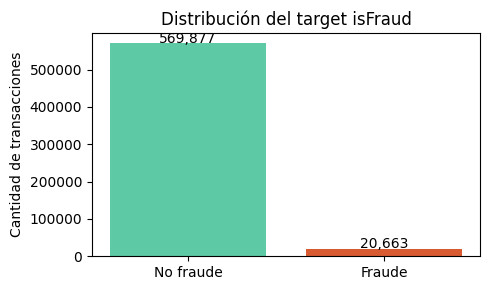

In [6]:
fraude_counts = train_txn["isFraud"].value_counts()
fraude_pct    = train_txn["isFraud"].value_counts(normalize=True) * 100

print("Distribución de isFraud")
print(f"  No fraude (0): {fraude_counts[0]:,}  ({fraude_pct[0]:.2f}%)")
print(f"  Fraude    (1): {fraude_counts[1]:,}  ({fraude_pct[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["No fraude", "Fraude"], fraude_counts.values,
       color=["#5DCAA5", "#D85A30"])
ax.set_title("Distribución del target isFraud")
ax.set_ylabel("Cantidad de transacciones")
for i, v in enumerate(fraude_counts.values):
    ax.text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 7. Análisis de valores faltantes

In [7]:
def missing_report(df, nombre):
    missings = df.isnull().sum()
    missings = missings[missings > 0].sort_values(ascending=False)
    pct      = (missings / len(df) * 100).round(2)
    report   = pd.DataFrame({"faltantes": missings, "porcentaje": pct})
    print(f"\n=== Missings en {nombre} ({len(missings)} columnas con NaN) ===")
    print(report.head(20))
    return report

missing_txn = missing_report(train_txn, "train_transaction")
missing_id  = missing_report(train_id,  "train_identity")


=== Missings en train_transaction (374 columnas con NaN) ===
       faltantes  porcentaje
dist2     552913       93.63
D7        551623       93.41
D13       528588       89.51
D14       528353       89.47
D12       525823       89.04
D6        517353       87.61
D8        515614       87.31
D9        515614       87.31
V154      508595       86.12
V153      508595       86.12
V162      508595       86.12
V161      508595       86.12
V163      508595       86.12
V155      508595       86.12
V156      508595       86.12
V138      508595       86.12
V142      508595       86.12
V149      508595       86.12
V148      508595       86.12
V147      508595       86.12

=== Missings en train_identity (38 columnas con NaN) ===
            faltantes  porcentaje
id_24          139486       96.71
id_25          139101       96.44
id_07          139078       96.43
id_08          139078       96.43
id_21          139074       96.42
id_26          139070       96.42
id_22          139064       96.42

## 8. Distribución de TransactionAmt por clase

Comparamos los montos de transacciones legítimas vs fraudulentas.

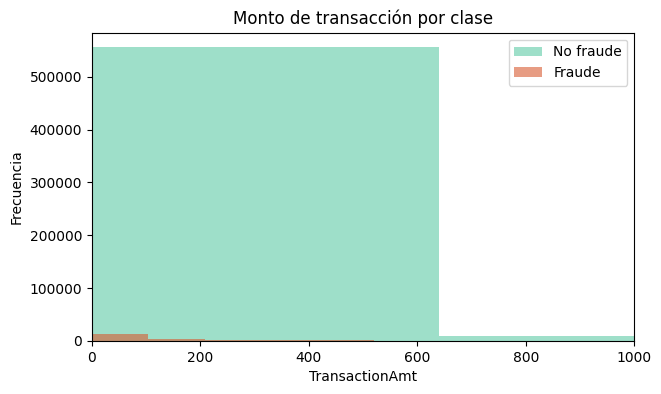

            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [8]:
# Separar montos por clase
monto_ok    = train_txn[train_txn["isFraud"] == 0]["TransactionAmt"]
monto_fraud = train_txn[train_txn["isFraud"] == 1]["TransactionAmt"]

# Histograma
plt.figure(figsize=(7, 4))
plt.hist(monto_ok,    bins=50, alpha=0.6, color="#5DCAA5", label="No fraude")
plt.hist(monto_fraud, bins=50, alpha=0.6, color="#D85A30", label="Fraude")
plt.xlim(0, 1000)
plt.title("Monto de transacción por clase")
plt.xlabel("TransactionAmt")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

# Estadísticas por clase
print(train_txn.groupby("isFraud")["TransactionAmt"].describe().round(2))

## 9. Patrones temporales del fraude

Analizamos si el fraude tiene patrones por hora del día.

C:\Users\micke\AppData\Local\Temp\ipykernel_163404\2761559424.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_txn["hour"] = (train_txn["TransactionDT"] // 3600) % 24


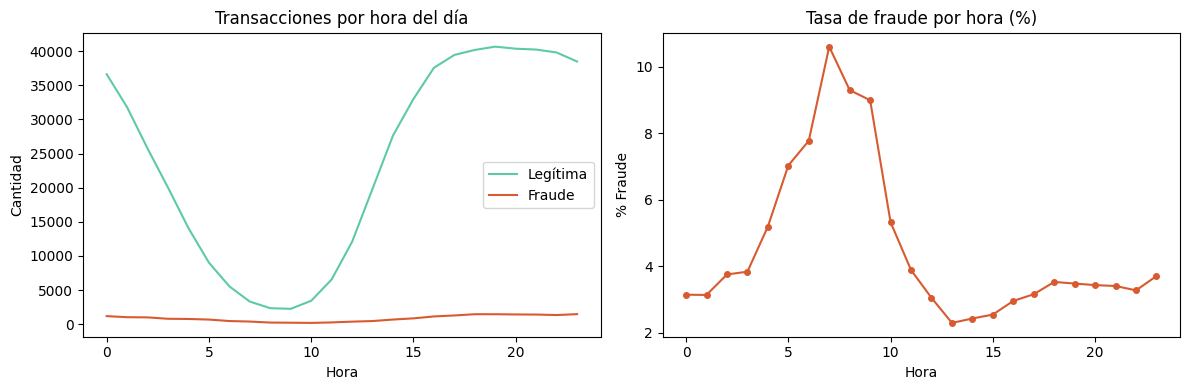

Hora con más fraude:   7h (10.6%)
Hora con menos fraude: 13h (2.3%)


In [9]:
train_txn["hour"] = (train_txn["TransactionDT"] // 3600) % 24

fraude_hora   = train_txn[train_txn["isFraud"] == 1]["hour"]
legitima_hora = train_txn[train_txn["isFraud"] == 0]["hour"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

legitima_hora.value_counts().sort_index().plot(ax=axes[0], color="#5DCAA5", label="Legítima")
fraude_hora.value_counts().sort_index().plot(ax=axes[0],   color="#D85A30", label="Fraude")
axes[0].set_title("Transacciones por hora del día")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Cantidad")
axes[0].legend()

tasa_fraude = train_txn.groupby("hour")["isFraud"].mean().mul(100)
tasa_fraude.plot(ax=axes[1], color="#D85A30", marker="o", markersize=4)
axes[1].set_title("Tasa de fraude por hora (%)")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("% Fraude")

plt.tight_layout()
plt.show()

print(f"Hora con más fraude:   {tasa_fraude.idxmax()}h ({tasa_fraude.max():.1f}%)")
print(f"Hora con menos fraude: {tasa_fraude.idxmin()}h ({tasa_fraude.min():.1f}%)")

## 10. Fraude por tipo de producto (ProductCD)

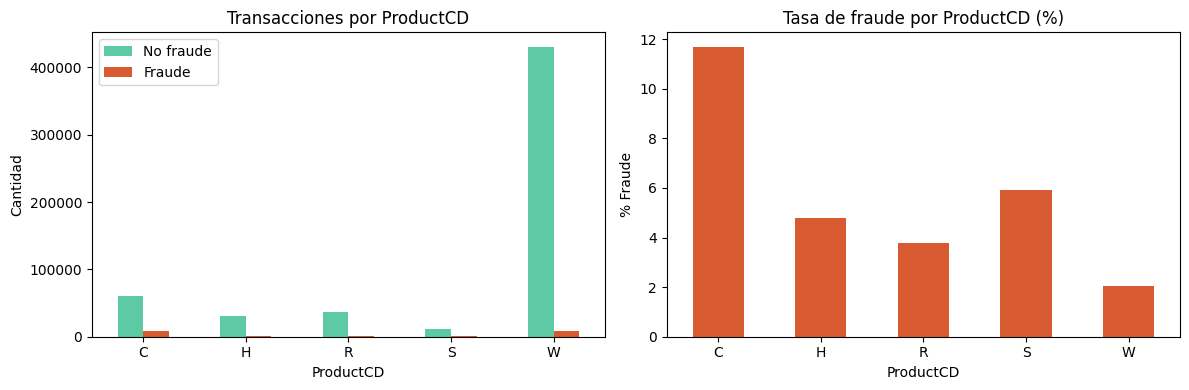

ProductCD
C    11.69
S     5.90
H     4.77
R     3.78
W     2.04
Name: isFraud, dtype: float64


In [10]:
# ProductCD es el tipo de producto comprado
conteo = train_txn.groupby(["ProductCD", "isFraud"]).size().unstack()
conteo.columns = ["No fraude", "Fraude"]

tasa = train_txn.groupby("ProductCD")["isFraud"].mean().mul(100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

conteo.plot(kind="bar", ax=axes[0], color=["#5DCAA5", "#D85A30"])
axes[0].set_title("Transacciones por ProductCD")
axes[0].set_xlabel("ProductCD")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=0)

tasa.plot(kind="bar", ax=axes[1], color="#D85A30")
axes[1].set_title("Tasa de fraude por ProductCD (%)")
axes[1].set_xlabel("ProductCD")
axes[1].set_ylabel("% Fraude")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(tasa.sort_values(ascending=False))

## 11. Fraude por tipo de tarjeta y banco emisor

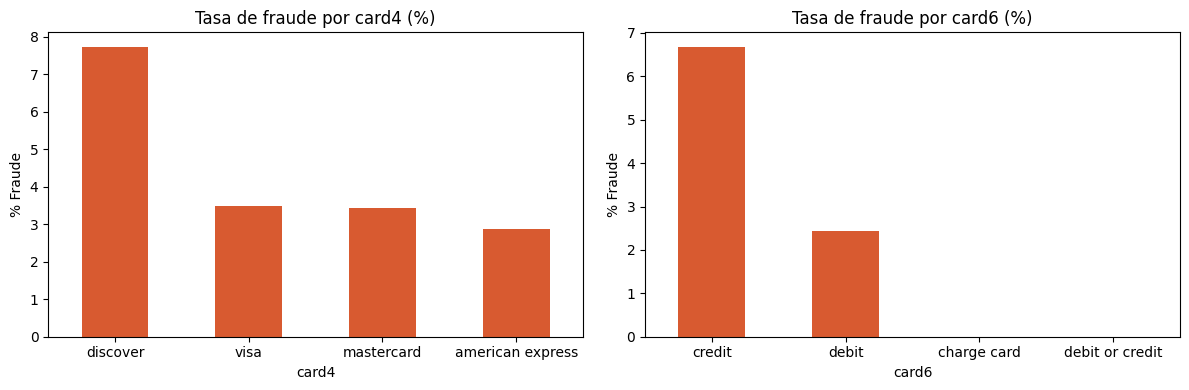

Tasa por card4:
card4
american express    2.87
discover            7.73
mastercard          3.43
visa                3.48
Name: isFraud, dtype: float64

Tasa por card6:
card6
charge card        0.00
credit             6.68
debit              2.43
debit or credit    0.00
Name: isFraud, dtype: float64


In [11]:
# Tipo de tarjeta (card4) y banco emisor (card6)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for col, ax in zip(["card4", "card6"], axes):
    tasa = train_txn.groupby(col)["isFraud"].mean().mul(100).sort_values(ascending=False)
    tasa.plot(kind="bar", ax=ax, color="#D85A30")
    ax.set_title(f"Tasa de fraude por {col} (%)")
    ax.set_xlabel(col)
    ax.set_ylabel("% Fraude")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("Tasa por card4:")
print(train_txn.groupby("card4")["isFraud"].mean().mul(100).round(2))

print("\nTasa por card6:")
print(train_txn.groupby("card6")["isFraud"].mean().mul(100).round(2))

## 12. Vista de datos de test

In [12]:
test_txn.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 13. Vista del dataset de identidad — train

In [13]:
train_id.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


## 14. Vista del dataset de identidad — test

In [14]:
test_id.head()

,TransactionID,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663586,-45.0,280290.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
1,3663588,0.0,3579.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,24.0,1280x720,match_status:2,T,F,T,T,mobile,LGLS676 Build/MXB48T
2,3663597,-5.0,185210.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,...,ie 11.0 for tablet,NaN,NaN,NaN,F,T,T,F,desktop,Trident/7.0
3,3663601,-45.0,252944.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
4,3663602,-95.0,328680.0,NaN,NaN,7.0,-33.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-G9650 Build/R16NW


## 15. Merge de transacciones e identidad

Unimos los datasets de transacciones e identidad usando  como llave.
Usamos  para preservar todas las transacciones aunque no tengan identidad.

In [15]:
# Unir transaction con identity
train = train_txn.merge(train_id, on="TransactionID", how="left")
test  = test_txn.merge(test_id,   on="TransactionID", how="left")

print("Train después del merge:", train.shape)
print("Test después del merge: ", test.shape)

# Verificar que no se perdieron filas
if len(train) == len(train_txn) and len(test) == len(test_txn):
    print("Merge correcto, no se perdieron filas")
else:
    print(f"ADVERTENCIA: train esperado {len(train_txn)}, obtenido {len(train)}")
    print(f"ADVERTENCIA: test esperado  {len(test_txn)},  obtenido {len(test)}")

# Guardar
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
train.to_csv(DATA_PROCESSED / "train_merged.parquet", index=False)
test.to_csv(DATA_PROCESSED / "test_merged.parquet",   index=False)

print("Archivos guardados en data/processed/")

Train después del merge: (590540, 435)
Test después del merge:  (506691, 433)
Merge correcto, no se perdieron filas
Archivos guardados en data/processed/
